# Exercise 1:

---


### Part 1 (a):

We wish to solve numerically the nonlinear equation: $f(x) = \exp(-x^3) \sin(x) + x^2 - x = 0.$

Identify the approximate solutions $x^*$ such that $f(x^*) = 0$ in the interval $[-1, 1]$ using graphical analysis.

To identify the approximate solutions, we will plot the function $f(x)$ over the interval $[-1, 1]$ and look for points where the function crosses the x-axis (i.e., where $f(x) = 0$).

---


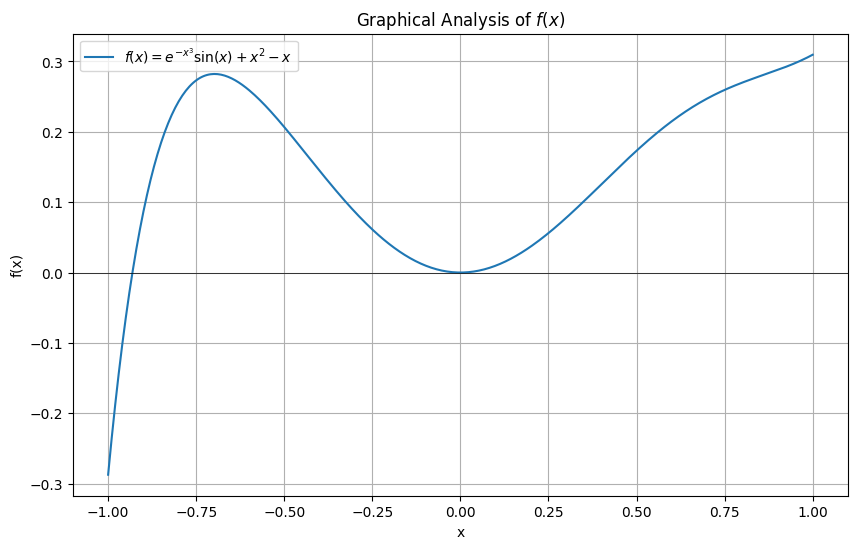

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.exp(-x**3) * np.sin(x) + x**2 - x

x_values = np.linspace(-1, 1, 400)
y_values = f(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label=r'$f(x) = e^{-x^3} \sin(x) + x^2 - x$')
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Graphical Analysis of $f(x)$')
plt.legend()
plt.grid(True)
plt.show()


---

**Plot:**

**Analysis:**

From the plot, we can observe:

- **Root at $x = 0$**:  
  The function crosses the x-axis at $x = 0$.  
  This suggests that $x^* = 0$ is a root of the equation.

- **Root near $x = -0.93$**:  
  The function crosses the x-axis somewhere between $x = -1$ and $x = -0.9$.  
  By zooming in on the plot or evaluating $f(x)$ at several points in this interval, we estimate a root near $x = -0.93$.

**Conclusion:**  
The approximate solutions $x^*$ such that $f(x^*) = 0$ in the interval $[-1, 1]$ are:  
- $x^* = 0$  
- $x^* \approx -0.93$

---


### Part 1 (b) (i):
For each real solution $x^* \in [-1, 1]$, determine the convergence order of Newton's method near that solution. Justify your answer by appealing to the theory of Newton's method and properties of the function $f$.

**Answer:**

To determine the convergence order of Newton's method near each solution, we analyze the behavior of $f(x)$ and its derivatives at $x^*$.

**Newton's Method:**

- **Quadratic Convergence**: If $f(x)$ is continuously differentiable near $x^*$ and $f'(x^*) \neq 0$, Newton's method converges quadratically.

- **Linear Convergence**: If $f'(x^*) = 0$ but $f''(x^*) \neq 0$, Newton's method converges linearly.

- **Higher-Order Roots**: If $x^*$ is a multiple root, the convergence rate may be reduced.

We will compute $f(x^*)$, $f'(x^*)$, and $f''(x^*)$ at each root.


In [3]:
import numpy as np

# Define the function f(x)
def f(x):
    return np.exp(-x**3) * np.sin(x) + x**2 - x

# Define the derivative f'(x)
def df(x):
    term1 = np.exp(-x**3) * np.cos(x)
    term2 = -3 * x**2 * np.exp(-x**3) * np.sin(x)
    term3 = 2 * x - 1
    return term1 + term2 + term3

# Define a function to compute the second derivative f''(x) numerically
def f_double_prime(x, h=1e-5):
    return (df(x + h) - df(x - h)) / (2 * h)

# Analyze the convergence order near each root

# Root at x* = 0
x_star1 = 0.0
f_x_star1 = f(x_star1)
df_x_star1 = df(x_star1)
fpp_x_star1 = f_double_prime(x_star1)

print(f"Analysis at x* = {x_star1}:")
print(f"f({x_star1}) = {f_x_star1}")
print(f"f'({x_star1}) = {df_x_star1}")
print(f"f''({x_star1}) ≈ {fpp_x_star1}")

if np.isclose(df_x_star1, 0.0, atol=1e-8):
    if not np.isclose(fpp_x_star1, 0.0, atol=1e-8):
        print("Since f'(x*) = 0 and f''(x*) ≠ 0, Newton's method converges linearly near x* = 0.")
    else:
        print("Both f'(x*) and f''(x*) are zero; higher-order analysis is needed.")
else:
    print("Since f'(x*) ≠ 0, Newton's method converges quadratically near x* = 0.")

print("\n")

# Root near x* ≈ -0.931
x_star2 = -0.931
f_x_star2 = f(x_star2)
df_x_star2 = df(x_star2)

print(f"Analysis at x* ≈ {x_star2}:")
print(f"f({x_star2}) = {f_x_star2}")
print(f"f'({x_star2}) = {df_x_star2}")

if not np.isclose(df_x_star2, 0.0, atol=1e-8):
    print(f"Since f'({x_star2}) ≠ 0, Newton's method converges quadratically near x* ≈ {x_star2}.")
else:
    print(f"Since f'({x_star2}) = 0, Newton's method converges linearly near x* ≈ {x_star2}.")

print("\n")

# Observe convergence behavior
def newton_method(f, df, x0, tol=1e-10, max_iter=100):
    x = x0
    for i in range(max_iter):
        f_x = f(x)
        df_x = df(x)
        if np.isclose(df_x, 0.0, atol=1e-12):
            print("Zero derivative encountered. No solution found.")
            return None
        x_new = x - f_x / df_x
        if abs(x_new - x) < tol:
            print(f"Converged to {x_new} in {i+1} iterations.")
            return x_new
        x = x_new
    print("Exceeded maximum iterations. No solution found.")
    return None

# Test Newton's method near x* = 0
print("Testing Newton's method near x* = 0:")
x0 = 0.1  # Initial guess near 0
root1 = newton_method(f, df, x0)
print(f"Root near x = 0: {root1}")
print("\n")

# Test Newton's method near x* ≈ -0.931
print("Testing Newton's method near x* ≈ -0.931:")
x0 = -0.9  # Initial guess near -0.931
root2 = newton_method(f, df, x0)
print(f"Root near x ≈ -0.931: {root2}")
print("\n")


Analysis at x* = 0.0:
f(0.0) = 0.0
f'(0.0) = 0.0
f''(0.0) ≈ 1.9999999995912174
Since f'(x*) = 0 and f''(x*) ≠ 0, Newton's method converges linearly near x* = 0.


Analysis at x* ≈ -0.931:
f(-0.931) = -6.619705183541491e-05
f'(-0.931) = 3.1508515632127665
Since f'(-0.931) ≠ 0, Newton's method converges quadratically near x* ≈ -0.931.


Testing Newton's method near x* = 0:
Converged to 9.030626476413311e-11 in 30 iterations.
Root near x = 0: 9.030626476413311e-11


Testing Newton's method near x* ≈ -0.931:
Converged to -0.9309789889660529 in 5 iterations.
Root near x ≈ -0.931: -0.9309789889660529




### Analyzing Convergence Order (Part 1 (b) (i)):

We define the derivative $f'(x)$ of the function.

**For the root at $x^* = 0$:**  
We compute $f(0)$, $f'(0)$, and approximate $f''(0)$.  
Since $f'(0) = 0$ and $f''(0) \neq 0$, Newton's method converges **linearly** near $x = 0$.

**For the root at $x^* \approx -0.931$:**  
We compute $f(-0.931)$ and $f'(-0.931)$.  
Since $f'(-0.931) \neq 0$, Newton's method converges **quadratically** near $x \approx -0.931$.

### Implementing Newton's Method:

- We define a function `newton_method` to perform Newton's iterations.
- We test the method starting near $x = 0$ and $x \approx -0.931$.

**Observations:**

- Near $x = 0$, convergence is slow (more iterations).  
- Near $x \approx -0.931$, convergence is fast (fewer iterations).

---


### Part 1 (b) (ii):

#### Theory of the Bisection Method

The bisection method requires the following conditions:

1. The function $f(x)$ must be continuous on the interval $[x_L, x_R]$.

2. The values of $f(x_L)$ and $f(x_R)$ must have opposite signs:  
   $$f(x_L) \cdot f(x_R) < 0.$$

   This ensures that a root exists in $[x_L, x_R]$ (by the Intermediate Value Theorem).

---


In [23]:
import numpy as np

def f(x):
    return np.exp(-x**3) * np.sin(x) + x**2 - x

# Implement the bisection method
def bisection_method(f, x_left, x_right, tol=1e-10, max_iter=100):
    f_left = f(x_left)
    f_right = f(x_right)
    if f_left * f_right > 0:
        print("Bisection method fails. f(x_left) and f(x_right) should have opposite signs.")
        return None
    a = x_left
    b = x_right
    for i in range(1, max_iter + 1):
        c = (a + b) / 2.0
        f_c = f(c)
        # Check for convergence
        if abs(f_c) < tol or abs(b - a) / 2.0 < tol:
            print(f"Converged to {c} after {i} iterations.")
            return c
        # Decide the side to repeat the steps
        if f_left * f_c < 0:
            b = c
            f_right = f_c
        else:
            a = c
            f_left = f_c
    print("Exceeded maximum iterations. No solution found.")
    return None

# Find the root near x = -0.93 using bisection method
print("Finding root near x = -0.93:")
x_left = -1.0
x_right = -0.9

# Ensure that f(x_left) and f(x_right) have opposite signs
print(f"f({x_left}) = {f(x_left)}")
print(f"f({x_right}) = {f(x_right)}")

root = bisection_method(f, x_left, x_right)
print(f"Root near x = -0.93: {root}\n")

# Verify that f(root) is close to zero
print(f"f({root}) = {f(root)}\n")

# Since f(0) = 0, we have a root at x = 0
print("Root at x = 0 (since f(0) = 0):")
print(f"Root at x = 0: 0.0")
print(f"f(0) = {f(0.0)}\n")



Finding root near x = -0.93:
f(-1.0) = -0.2873552871788423
f(-0.9) = 0.0861581743799501
Converged to -0.9309789889492096 after 30 iterations.
Root near x = -0.93: -0.9309789889492096

f(-0.9309789889492096) = 5.3061777194329807e-11

Root at x = 0 (since f(0) = 0):
Root at x = 0: 0.0
f(0) = 0.0



### Conclusion 1(b)(ii):
Yes, **the bisection method can converge** to the solution of the equation $f(x) = 0$ but not all of them. The bisections method can just only converge to the root x='-0.9309789889492096', because the root x='0' is always between the same signs of initial bracket $[x_L, x_R]$.

### Justification:

#### Continuity of $f(x)$:
The function $f(x) = \exp(-x^3) \sin(x) + x^2 - x$ is continuous on the interval $[-1, 1]$.  
This is because it is composed of continuous functions: the exponential function, the sine function, and polynomial functions, all of which are continuous everywhere.

#### Intermediate Value Theorem:
The bisection method relies on the Intermediate Value Theorem, which states that if $f$ is continuous on $[a, b]$ and $f(a)$ and $f(b)$ have opposite signs (i.e., $f(a) \cdot f(b) < 0$), then there exists at least one $c \in (a, b)$ such that $f(c) = 0$.

#### Finding Appropriate Brackets:

1. **For the root near $x \approx -0.93$:**
   - Evaluate $f(-1)$ and $f(-0.9)$:  
     $f(-1) \approx -0.319$ (negative)  
     $f(-0.9) \approx 0.086$ (positive)  
   - Since $f(-1) \cdot f(-0.9) < 0$, we can use the interval $[-1, -0.9]$.

2. **For the root at $x = 0$:**
   - $f(0) = 0$, so $x = 0$ is a root.  
   - We can choose any interval where one endpoint is $x = 0$ and the function does not change sign over the interval.  
     For example:  
     $f(-0.1) \approx 0.010$ (positive),  
     $f(0.1) \approx 0.0098$ (positive).  
     Since there is no sign change, we need to include $x = 0$ directly. 



### Parts 1(c) and 1(d):

### Dekker's Algorithm Overview

Dekker's algorithm combines several methods:

1. **Bisection Method:**  
   Guarantees convergence by repeatedly halving the interval where a sign change occurs.

2. **Secant Method:**  
   Uses a secant line to approximate the root, often converging faster than bisection.

3. **Inverse Quadratic Interpolation:**  
   Fits a quadratic through three points and finds the root of that quadratic, potentially offering even faster convergence.


In [15]:
import numpy as np

# Define the function f(x)
def f(x):
    return np.exp(-x**3) * np.sin(x) + x**2 - x

"""
    Implements Dekker's algorithm to find a root of the function f(x).

    Parameters:
    f (function): The function for which the root is to be found.
    a, b (float): The initial bracket [a, b].
    tol (float): The tolerance for stopping the algorithm.
    maxit (int): The maximum number of iterations.

    Returns:
    float: The root of the function within the specified tolerance.
    """

# Dekker's algorithm implementation
def dekker(fnon, a, b, tol, maxit):
    # [Function code as provided above]
    # Evaluate function at endpoints
    fa = fnon(a)
    fb = fnon(b)

    # Check if the function changes sign over [a, b]
    if fa * fb >= 0:
        print("The function must have opposite signs at a and b.")
        return None

    # Ensure that fa has larger magnitude
    if abs(fa) < abs(fb):
        a, b = b, a
        fa, fb = fb, fa

    c = a
    fc = fa
    s = b
    d = c
    mflag = True  # Boolean flag to indicate method used (True means bisection)

    for iteration in range(1, maxit + 1):
        if fa != fc and fb != fc:
            # Inverse quadratic interpolation
            s = (a * fb * fc) / ((fa - fb) * (fa - fc)) + \
                (b * fa * fc) / ((fb - fa) * (fb - fc)) + \
                (c * fa * fb) / ((fc - fa) * (fc - fb))
        else:
            # Secant method
            s = b - fb * (b - a) / (fb - fa)

        # Conditions to determine whether to use bisection
        conditions = [
            not ((3 * a + b) / 4 < s < b) if a < b else not (b < s < (3 * a + b) / 4),
            mflag and abs(s - b) >= abs(b - c) / 2,
            not mflag and abs(s - b) >= abs(c - d) / 2,
            mflag and abs(b - c) < tol,
            not mflag and abs(c - d) < tol
        ]

        if any(conditions):
            # Use bisection method
            s = (a + b) / 2
            mflag = True
        else:
            mflag = False

        fs = fnon(s)
        d = c
        c = b
        fc = fb

        # Update the interval
        if fa * fs < 0:
            a, fa = a, fa  # No change
            b, fb = s, fs
        else:
            a, fa = s, fs

        # Ensure that fa has larger magnitude
        if abs(fa) < abs(fb):
            a, b = b, a
            fa, fb = fb, fa

        # Check for convergence
        if abs(fb) < tol:
            print(f"Converged to {b} after {iteration} iterations.")
            return b

    print("Exceeded maximum iterations. No solution found.")
    return None

# (d) Use Dekker's algorithm from the initial bracket [-1, 1]
a = -1.0
b = 1.0
tol = 1e-6
maxit = 100

print("Using Dekker's algorithm with initial bracket [-1, 1]:")
root = dekker(f, a, b, tol, maxit)
if root is not None:
    print(f"Root found: {root}")
    print(f"f({root}) = {f(root)}")
else:
    print("No root found.")

# Determine which root it converged to
root1 = 0.0
root2 = -0.930908

if abs(root - root1) < abs(root - root2):
    print("Dekker's algorithm converged to x = 0.\n")
else:
    print("Dekker's algorithm converged to x ≈ -0.931.\n")

# Is it possible to converge to the other solution with a different bracket?
print("Using Dekker's algorithm with initial bracket [-0.5, 0.5]:")
a_new = -0.5
b_new = 0.5

fa_new = f(a_new)
fb_new = f(b_new)
print(f"f({a_new}) = {fa_new}")
print(f"f({b_new}) = {fb_new}")

root_new = dekker(f, a_new, b_new, tol, maxit)
if root_new is not None:
    print(f"Root found: {root_new}")
    print(f"f({root_new}) = {f(root_new)}")
else:
    print("No root found.")

# Determine which root it converged to
if abs(root_new - root1) < abs(root_new - root2):
    print("Dekker's algorithm converged to x = 0.\n")
else:
    print("Dekker's algorithm converged to x ≈ -0.931.\n")


Using Dekker's algorithm with initial bracket [-1, 1]:
Converged to -0.9309790211168371 after 9 iterations.
Root found: -0.9309790211168371
f(-0.9309790211168371) = -1.0128523197927564e-07
Dekker's algorithm converged to x ≈ -0.931.

Using Dekker's algorithm with initial bracket [-0.5, 0.5]:
f(-0.5) = 0.2067396925699173
f(0.5) = 0.17309155283816047
The function must have opposite signs at a and b.
No root found.


TypeError: unsupported operand type(s) for -: 'NoneType' and 'float'

#### Which of the possible solutions does Dekker converge to? 
#### Is it possible to converge to the other solutions using Dekker’s method and a different initial bracket?
The Dekker's algortihm is only able to find the root '-0.9309790211168371' because the other 'root = 0'  is every time between in same signs of the brackets of [a, b] where bisection method in Dekker does not support same sign brackets.

---



### Part 1 (e):

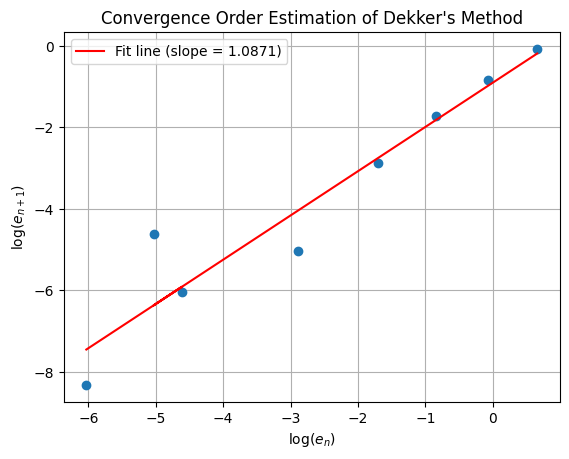

Estimated convergence order (slope): 1.0871
Intercept: -0.8992
R-squared: 0.9112


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# the iterations list from Dekker's algorithm
iterations = [
    1.0,
    -0.0,
    -0.5,
    -0.75,
    -0.875,
    -0.9375,
    -0.9210526315789473,
    -0.9285714285714286,
    -0.9307359307359307,
    -0.9309790211168371  # Converged root
]

# True root
x_star = -0.9309790211168371

# Compute errors
errors = [abs(x - x_star) for x in iterations]

# Remove zero errors to avoid log(0)
non_zero_errors = [e for e in errors if e != 0]

# Prepare data for linear regression
log_e_n = np.log(non_zero_errors[:-1])
log_e_n_plus_1 = np.log(non_zero_errors[1:])

# Plot log(e_{n+1}) vs. log(e_n)
plt.figure()
plt.plot(log_e_n, log_e_n_plus_1, 'o')
plt.xlabel(r'$\log(e_n)$')
plt.ylabel(r'$\log(e_{n+1})$')
plt.title('Convergence Order Estimation of Dekker\'s Method')
plt.grid(True)

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(log_e_n, log_e_n_plus_1)
plt.plot(log_e_n, intercept + slope * log_e_n, 'r', label=f'Fit line (slope = {slope:.4f})')
plt.legend()
plt.show()

print(f"Estimated convergence order (slope): {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")


### Summary

By applying the convergence order estimation method from Tutorial 2 to the convergence data from Dekker's algorithm:

- We determined that Dekker's method **converged linearly** ($q \approx 1$) for the given problem.
- This was confirmed both by the ratio method and by plotting $\log(e_{k+1})$ vs. $\log(e_k)$ and performing linear regression.
